# Product Sales Prediction - Complete Machine Learning Workflow

Notebook nay trien khai day du yeu cau bai Practice 2: Predicting Product Sales.

Quy trinh:
1. Problem definition
2. Data loading va data validation
3. Data cleaning
4. Exploratory Data Analysis (EDA)
5. Feature engineering
6. Train/test split theo thoi gian
7. Model training
8. Model evaluation
9. Chon final model va luu artifact
10. Demo prediction

Target variable: `Revenue`.

Chu y leakage: `Revenue = Quantity * Unit_Price`, nen notebook train 2 phien ban:
- Model A: co `Quantity`, dung de minh hoa leakage.
- Model B: khong co `Quantity`, dung lam model chinh thuc te.

## 1. Problem Definition

Muc tieu cua bai toan la du doan doanh thu san pham/don hang de ho tro inventory management va marketing strategy.

- Problem type: Regression
- Target: `Revenue`
- Main metric: RMSE va MAE
- Secondary metric: R2
- Data source: `data/product_sales_dataset_final.csv`

In [1]:
from __future__ import annotations

import json
from pathlib import Path
from typing import Any

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.tree import DecisionTreeRegressor

try:
    display
except NameError:
    display = print

plt.style.use("default")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_PATH = PROJECT_ROOT / "data" / "product_sales_dataset_final.csv"
REPORT_DIR = PROJECT_ROOT / "reports"
PLOT_DIR = REPORT_DIR / "plots"
ARTIFACT_DIR = PROJECT_ROOT / "artifacts"

REPORT_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR.mkdir(parents=True, exist_ok=True)
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

TARGET = "Revenue"
DATE_COLUMN = "Order_Date"
DATE_FORMAT = "%m-%d-%y"
RANDOM_STATE = 42
TEST_START_DATE = pd.Timestamp("2024-10-01")

DATA_PATH

PosixPath('/Users/quangmanh/Project/lab02/data/product_sales_dataset_final.csv')

## 2. Load Data

In [2]:
df_raw = pd.read_csv(DATA_PATH)
print("Raw shape:", df_raw.shape)
df_raw.head()

Raw shape: (200000, 14)


,Order_ID,Order_Date,Customer_Name,City,State,Region,Country,Category,Sub_Category,Product_Name,Quantity,Unit_Price,Revenue,Profit
0,1,08-23-23,Bianca Brown,Jackson,Mississippi,South,United States,Accessories,Small Electronics,Phone Case,3,201.01,603.03,221.49
1,2,12-20-24,Jared Edwards,Grand Rapids,Michigan,Centre,United States,Accessories,Small Electronics,Charging Cable,4,74.30,297.20,97.09
2,3,01-29-24,Susan Valdez,Minneapolis,Minnesota,Centre,United States,Clothing & Apparel,Sportswear,Nike Air Force 1,1,68.19,68.19,25.47
3,4,11-29-24,Tina Williams,Tallahassee,Florida,South,United States,Clothing & Apparel,Sportswear,Adidas Tracksuit,3,209.64,628.92,231.38
4,5,09-21-23,Catherine Gordon,Baltimore,Maryland,East,United States,Accessories,Bags,Backpack,1,216.63,216.63,42.46


## 3. Data Cleaning va Validation

Cac buoc theo requirements:
- Chuan hoa ten cot.
- Parse date.
- Kiem tra missing values.
- Kiem tra duplicate rows.
- Kiem tra cong thuc `Revenue = Quantity * Unit_Price`.
- Ghi ro cot nao khong dung lam feature de tranh leakage/noise.

In [3]:
df = df_raw.copy()
original_columns = list(df.columns)
df.columns = df.columns.str.strip()
stripped_columns = [c for c in original_columns if c != c.strip()]

required_columns = [
    "Order_ID", "Order_Date", "Customer_Name", "City", "State", "Region", "Country",
    "Category", "Sub_Category", "Product_Name", "Quantity", "Unit_Price", "Revenue", "Profit"
]
missing_required = sorted(set(required_columns).difference(df.columns))
if missing_required:
    raise ValueError(f"Missing required columns: {missing_required}")

df[DATE_COLUMN] = pd.to_datetime(df[DATE_COLUMN], format=DATE_FORMAT, errors="coerce")
formula_diff = (df["Revenue"].round(2) - (df["Quantity"] * df["Unit_Price"]).round(2)).abs()

data_checks = {
    "rows": int(df.shape[0]),
    "columns": int(df.shape[1]),
    "stripped_columns": stripped_columns,
    "missing_total": int(df.isna().sum().sum()),
    "duplicate_rows": int(df.duplicated().sum()),
    "date_parse_failures": int(df[DATE_COLUMN].isna().sum()),
    "date_min": str(df[DATE_COLUMN].min().date()),
    "date_max": str(df[DATE_COLUMN].max().date()),
    "revenue_formula_mismatch_rows": int((formula_diff > 0.01).sum()),
    "revenue_formula_max_abs_diff": float(formula_diff.max()),
}

assert not df.columns.str.contains(r"^\s|\s$").any(), "Column names still contain leading/trailing spaces"
assert data_checks["missing_total"] == 0, "Dataset contains missing values"
assert data_checks["duplicate_rows"] == 0, "Dataset contains duplicate rows"
assert data_checks["date_parse_failures"] == 0, "Order_Date parse failed"
assert data_checks["revenue_formula_mismatch_rows"] == 0, "Revenue formula check failed"

data_checks

{'rows': 200000,
 'columns': 14,
 'stripped_columns': [' Unit_Price ', ' Revenue ', ' Profit '],
 'missing_total': 0,
 'duplicate_rows': 0,
 'date_parse_failures': 0,
 'date_min': '2023-01-01',
 'date_max': '2024-12-31',
 'revenue_formula_mismatch_rows': 0,
 'revenue_formula_max_abs_diff': 0.0}

In [4]:
print("Data types:")
display(df.dtypes)

print("Missing values by column:")
display(pd.DataFrame({"missing": df.isna().sum(), "pct": df.isna().mean() * 100}))

print("Numeric summary:")
display(df[["Quantity", "Unit_Price", "Revenue", "Profit"]].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).T)

print("Cardinality:")
display(df.nunique().sort_values(ascending=False))

Data types:


Order_ID                  int64
Order_Date       datetime64[us]
Customer_Name               str
City                        str
State                       str
Region                      str
Country                     str
Category                    str
Sub_Category                str
Product_Name                str
Quantity                  int64
Unit_Price              float64
Revenue                 float64
Profit                  float64
dtype: object

Missing values by column:


,missing,pct
Order_ID,0,0.0
Order_Date,0,0.0
Customer_Name,0,0.0
City,0,0.0
State,0,0.0
Region,0,0.0
Country,0,0.0
Category,0,0.0
Sub_Category,0,0.0
Product_Name,0,0.0


Numeric summary:


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
Quantity,200000.0,1.854000,1.100536,1.00,1.0000,1.00,1.0000,1.000,2.0000,4.0000,5.0000,11.00
Unit_Price,200000.0,382.855615,276.870235,17.03,33.7999,64.35,162.7600,303.545,562.2525,917.5600,1135.1613,1432.00
Revenue,200000.0,712.038725,742.471556,17.03,45.9600,85.14,229.1875,464.880,881.3025,2238.0045,3607.0494,9014.25
Profit,200000.0,157.743041,155.689581,3.92,11.7900,22.36,59.2100,109.530,199.4025,459.5505,766.3413,2763.72


Cardinality:


Order_ID         200000
Customer_Name    120230
Revenue          106202
Unit_Price        80524
Profit            46935
Order_Date          731
City                108
Product_Name         49
State                47
Sub_Category         19
Quantity             11
Region                4
Category              4
Country               1
dtype: int64

## 4. EDA - Target Distribution

In [5]:
target_summary = {
    "mean": df[TARGET].mean(),
    "median": df[TARGET].median(),
    "std": df[TARGET].std(),
    "min": df[TARGET].min(),
    "max": df[TARGET].max(),
    "skew": df[TARGET].skew(),
}
display(pd.Series(target_summary).round(4))
display(df[TARGET].quantile([.01, .05, .25, .5, .75, .95, .99]).round(2))

mean       712.0387
median     464.8800
std        742.4716
min         17.0300
max       9014.2500
skew         2.5357
dtype: float64

0.01      45.96
0.05      85.14
0.25     229.19
0.50     464.88
0.75     881.30
0.95    2238.00
0.99    3607.05
Name: Revenue, dtype: float64

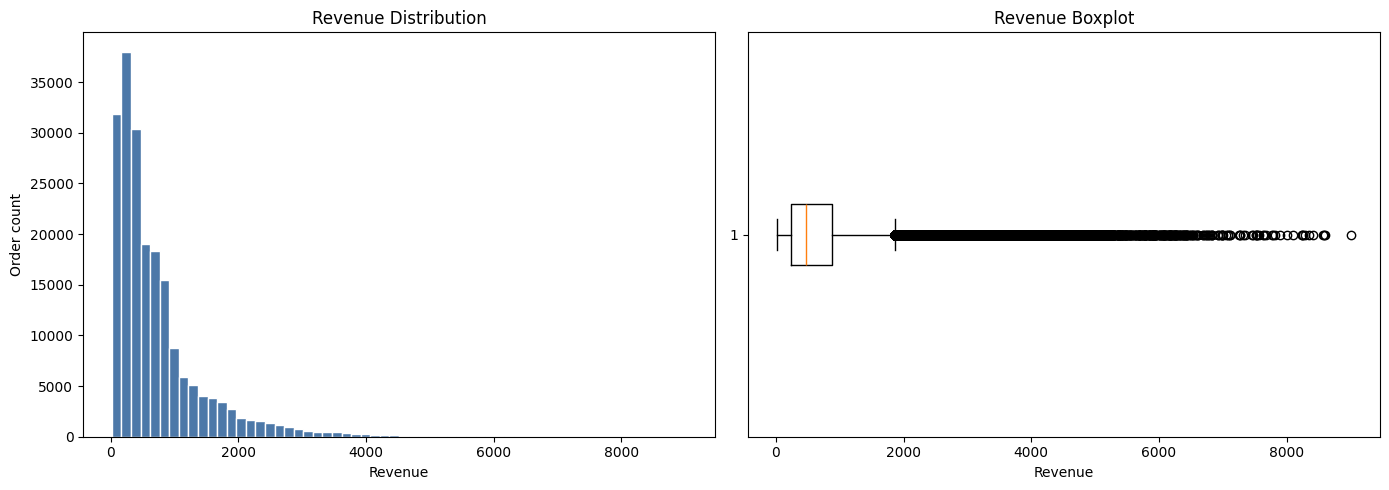

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df[TARGET], bins=60, color="#4c78a8", edgecolor="white")
axes[0].set_title("Revenue Distribution")
axes[0].set_xlabel("Revenue")
axes[0].set_ylabel("Order count")

axes[1].boxplot(df[TARGET], vert=False)
axes[1].set_title("Revenue Boxplot")
axes[1].set_xlabel("Revenue")

plt.tight_layout()
plt.savefig(PLOT_DIR / "notebook_revenue_distribution_boxplot.png", dpi=160)
plt.show()

Nhan xet EDA target:
- `Revenue` bi lech phai, nen can bao cao ca MAE va RMSE.
- RMSE se phat nang cac loi o don hang doanh thu cao.
- Neu muon cai thien them co the thu `log1p(Revenue)`, nhung notebook nay giu target goc de metric de dien giai.

## 5. EDA - Product, Geography, Time

In [7]:
def group_sales(data: pd.DataFrame, group_col: str, n: int = 10) -> pd.DataFrame:
    return (
        data.groupby(group_col)
        .agg(
            orders=("Order_ID", "count"),
            quantity=("Quantity", "sum"),
            revenue=("Revenue", "sum"),
            avg_revenue=("Revenue", "mean"),
            median_revenue=("Revenue", "median"),
        )
        .sort_values("revenue", ascending=False)
        .head(n)
        .round(2)
    )

top_category = group_sales(df, "Category")
top_sub_category = group_sales(df, "Sub_Category")
top_product = group_sales(df, "Product_Name")
top_region = group_sales(df, "Region")
top_state = group_sales(df, "State")
top_city = group_sales(df, "City")

display(top_category)
display(top_sub_category)
display(top_product)
display(top_region)
display(top_state)
display(top_city)

,orders,quantity,revenue,avg_revenue,median_revenue
Category,,,,,
Electronics,51230,97115,57485698.06,1122.11,837.06
Home & Furniture,50564,90403,47674426.96,942.85,709.31
Clothing & Apparel,62298,115523,27134365.30,435.56,331.27
Accessories,35908,67759,10113254.61,281.64,213.30


,orders,quantity,revenue,avg_revenue,median_revenue
Sub_Category,,,,,
Bedding,10171,18575,13042783.30,1282.35,975.00
Laptops,8656,17630,12358319.81,1427.72,1037.54
Smartphones,8442,16985,10904335.31,1291.68,951.83
Furniture,10096,19002,9697778.92,960.56,722.46
Wearables,8563,16755,9216507.48,1076.32,810.12
Kitchenware,10091,19541,9117341.17,903.51,676.86
Home Appliances,8360,16080,8638544.88,1033.32,789.34
Tablets,8557,15187,8373830.76,978.59,760.46
Home Decor,10165,17024,8070216.82,793.92,625.06


,orders,quantity,revenue,avg_revenue,median_revenue
Product_Name,,,,,
Tempur-Pedic Mattress,5523,10333,9061755.86,1640.73,1221.98
Instant Pot,8657,18200,8903475.26,1028.47,768.11
MacBook Air,3926,8763,7362516.81,1875.32,1464.60
Apple Watch,5931,12368,6834472.35,1152.33,860.82
Apple iPhone 14,3636,7642,5740819.18,1578.88,1167.65
iPad Pro,5421,10075,5574458.89,1028.31,781.94
KitchenAid Mixer,5376,9831,4989740.69,928.15,703.52
Storage Rack,5707,9394,4463941.27,782.19,614.98
Brooklinen Sheets,4648,8242,3981027.44,856.50,660.93


,orders,quantity,revenue,avg_revenue,median_revenue
Region,,,,,
East,57034,105965,44980048.22,788.65,547.19
West,55428,102931,36242841.73,653.87,416.57
Centre,49603,91464,36081894.34,727.41,482.19
South,37935,70440,25102960.64,661.74,428.53


,orders,quantity,revenue,avg_revenue,median_revenue
State,,,,,
California,10272,19061,6766728.65,658.75,413.42
Arizona,10262,19032,6668187.20,649.79,411.23
New Jersey,5780,10712,4552067.75,787.55,548.01
Vermont,5677,10582,4550459.19,801.56,552.64
New York,5766,10730,4541307.27,787.60,551.28
Connecticut,5726,10666,4515748.44,788.64,545.68
Delaware,5673,10565,4515199.69,795.91,554.96
Pennsylvania,5765,10756,4495637.28,779.82,552.50
New Hampshire,5682,10532,4489012.87,790.04,539.04


,orders,quantity,revenue,avg_revenue,median_revenue
City,,,,,
Burlington,2920,5487,2367578.63,810.81,564.22
Manchester,2912,5349,2316261.28,795.42,548.09
Rochester,2905,5416,2312165.68,795.93,556.44
Wilmington,2874,5406,2311588.97,804.31,560.91
Providence,2901,5355,2298465.51,792.30,537.81
Jersey City,2905,5343,2290243.36,788.38,556.06
Boston,2878,5353,2274264.86,790.22,531.81
Philadelphia,2833,5279,2262453.14,798.61,571.82
Newark,2875,5369,2261824.39,786.72,541.26


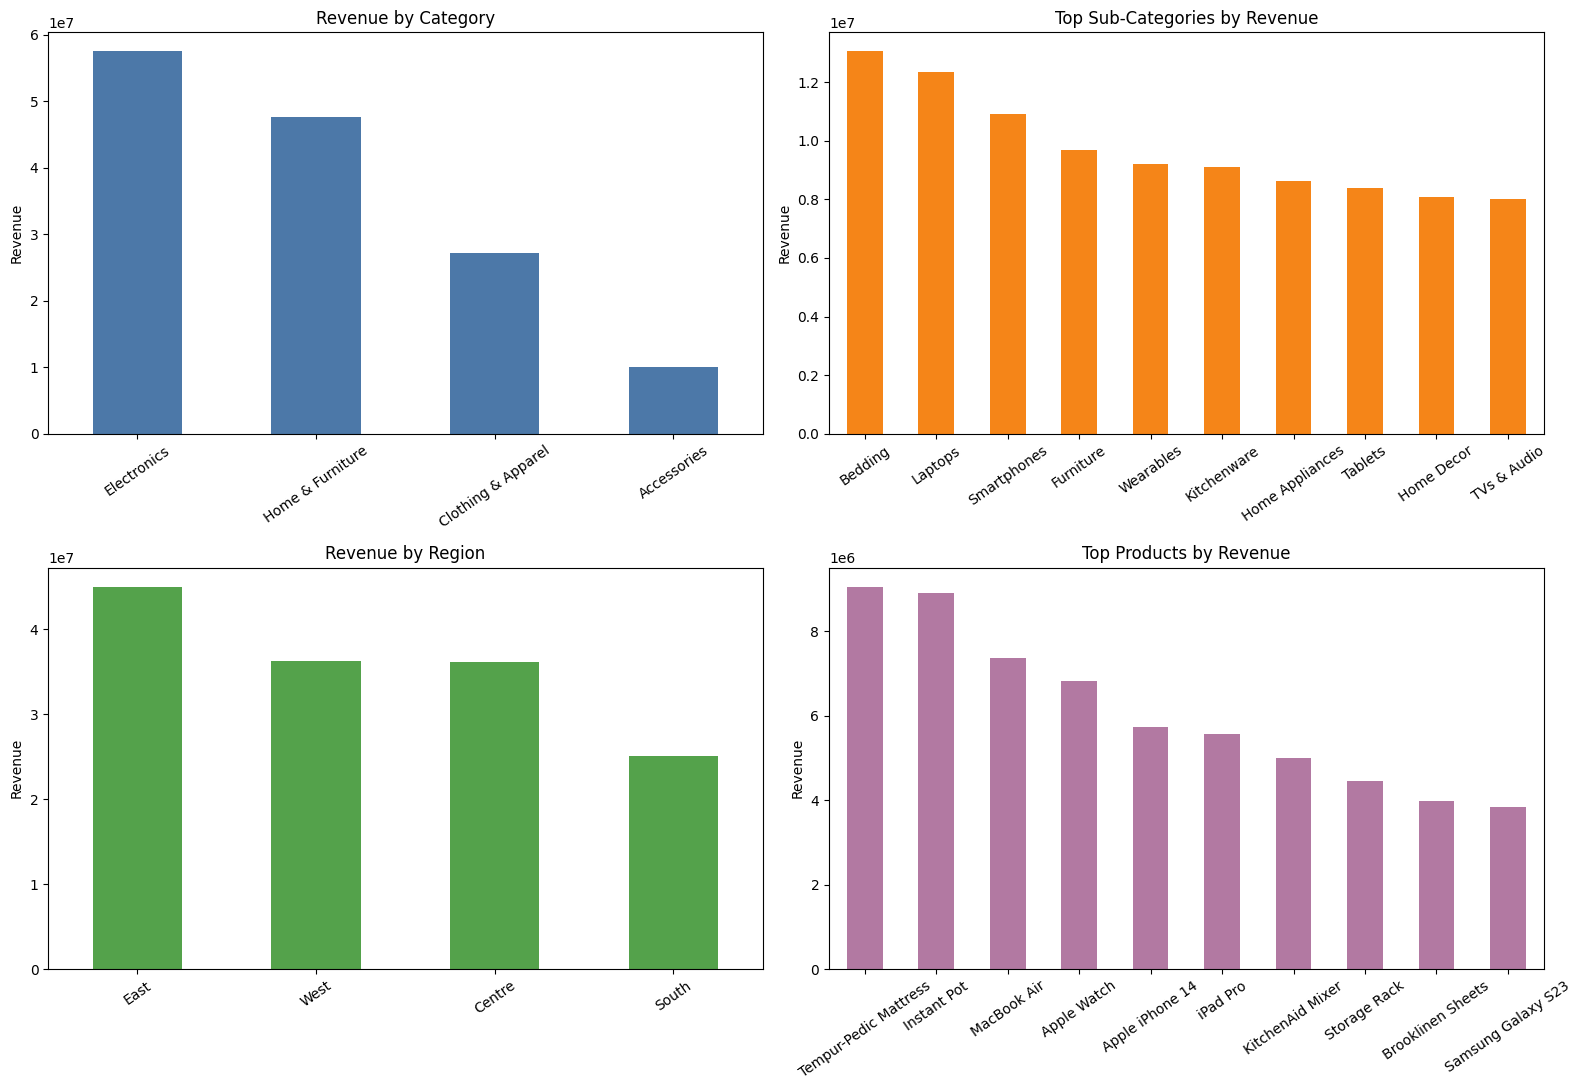

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

top_category["revenue"].plot(kind="bar", ax=axes[0, 0], color="#4c78a8", title="Revenue by Category")
top_sub_category["revenue"].head(10).plot(kind="bar", ax=axes[0, 1], color="#f58518", title="Top Sub-Categories by Revenue")
top_region["revenue"].plot(kind="bar", ax=axes[1, 0], color="#54a24b", title="Revenue by Region")
top_product["revenue"].head(10).plot(kind="bar", ax=axes[1, 1], color="#b279a2", title="Top Products by Revenue")

for ax in axes.ravel():
    ax.set_xlabel("")
    ax.set_ylabel("Revenue")
    ax.tick_params(axis="x", rotation=35)

plt.tight_layout()
plt.savefig(PLOT_DIR / "notebook_product_geography_eda.png", dpi=160)
plt.show()

Order_Date
2023    70755372.66
2024    71652372.27
Name: Revenue, dtype: float64

Order_Date
2023Q1    11034564.44
2023Q2    13884013.74
2023Q3    13518012.68
2023Q4    32318781.80
2024Q1    11386883.10
2024Q2    13868467.20
2024Q3    13643435.40
2024Q4    32753586.57
Freq: Q-DEC, Name: Revenue, dtype: float64

Order_Date
Friday       23257334.62
Sunday       22234744.27
Saturday     21446039.30
Monday       20868890.69
Wednesday    18367437.36
Thursday     18197562.48
Tuesday      18035736.21
Name: Revenue, dtype: float64

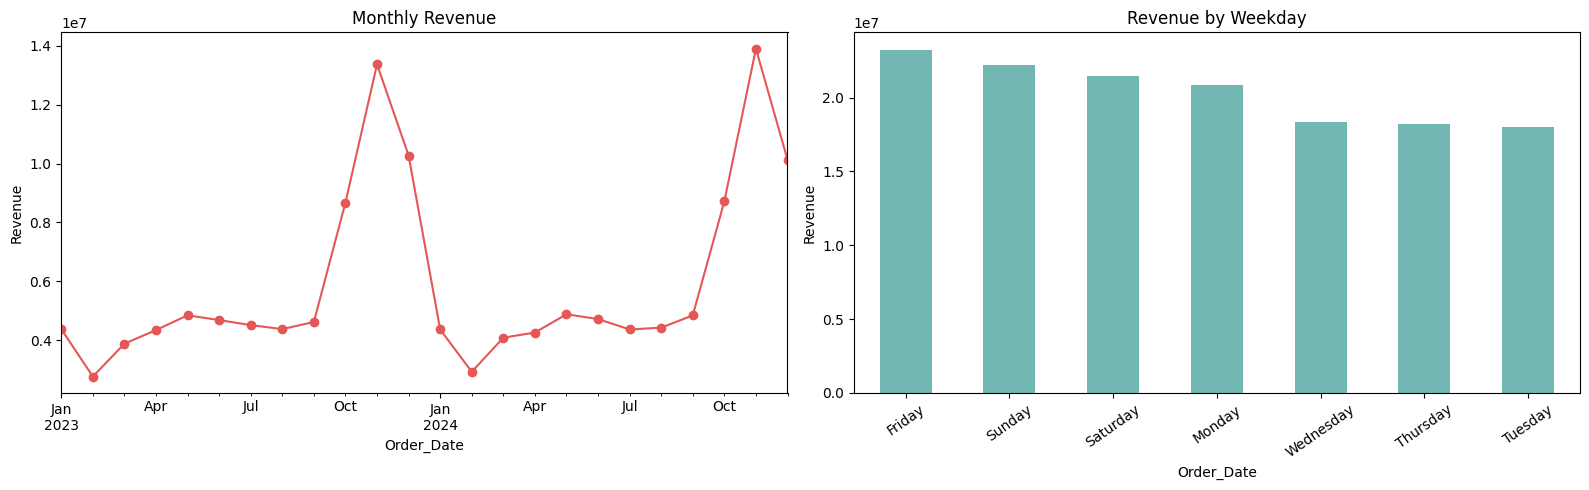

In [9]:
monthly_revenue = df.set_index(DATE_COLUMN).resample("ME")[TARGET].sum()
quarterly_revenue = df.groupby(df[DATE_COLUMN].dt.to_period("Q"))[TARGET].sum()
weekday_revenue = df.groupby(df[DATE_COLUMN].dt.day_name())[TARGET].sum().sort_values(ascending=False)
yearly_revenue = df.groupby(df[DATE_COLUMN].dt.year)[TARGET].sum()

display(yearly_revenue.round(2))
display(quarterly_revenue.round(2))
display(weekday_revenue.round(2))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
monthly_revenue.plot(ax=axes[0], marker="o", color="#e45756", title="Monthly Revenue")
weekday_revenue.plot(kind="bar", ax=axes[1], color="#72b7b2", title="Revenue by Weekday")
axes[0].set_ylabel("Revenue")
axes[1].set_ylabel("Revenue")
axes[1].tick_params(axis="x", rotation=35)
plt.tight_layout()
plt.savefig(PLOT_DIR / "notebook_time_eda.png", dpi=160)
plt.show()

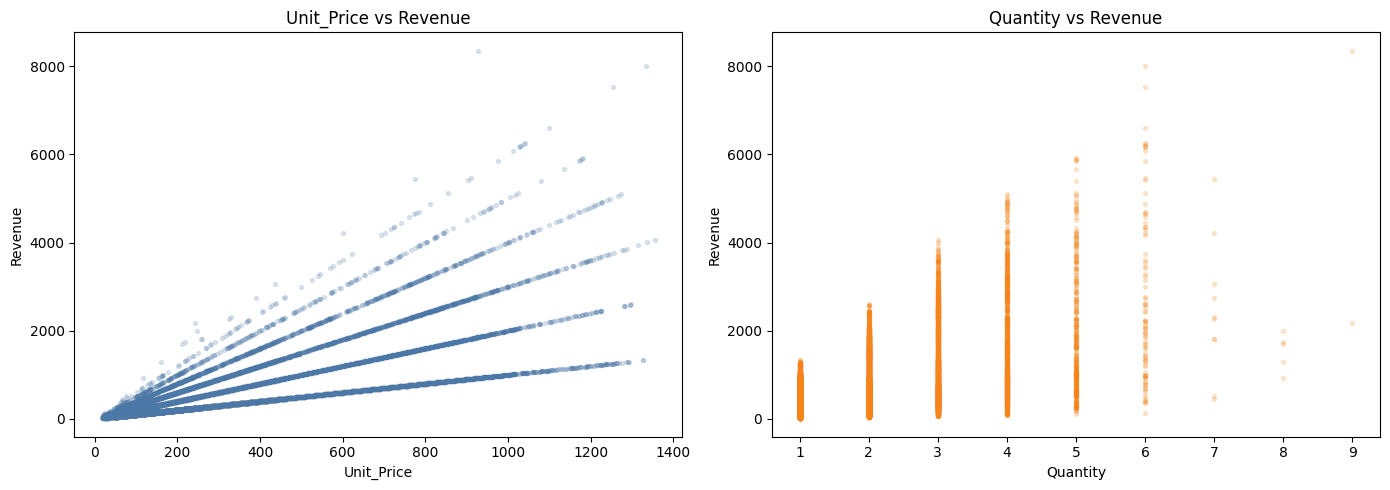

,Quantity,Unit_Price,Revenue,Profit
Quantity,1.0000,0.0073,0.5772,0.6025
Unit_Price,0.0073,1.0000,0.7062,0.5287
Revenue,0.5772,0.7062,1.0000,0.8413
Profit,0.6025,0.5287,0.8413,1.0000


In [10]:
sample = df.sample(n=min(15000, len(df)), random_state=RANDOM_STATE)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(sample["Unit_Price"], sample[TARGET], alpha=0.18, s=8, color="#4c78a8")
axes[0].set_title("Unit_Price vs Revenue")
axes[0].set_xlabel("Unit_Price")
axes[0].set_ylabel("Revenue")

axes[1].scatter(sample["Quantity"], sample[TARGET], alpha=0.18, s=8, color="#f58518")
axes[1].set_title("Quantity vs Revenue")
axes[1].set_xlabel("Quantity")
axes[1].set_ylabel("Revenue")

plt.tight_layout()
plt.savefig(PLOT_DIR / "notebook_relationship_eda.png", dpi=160)
plt.show()

display(df[["Quantity", "Unit_Price", "Revenue", "Profit"]].corr().round(4))

## 5.1. EDA Nang Cao - Them Tu Notebook Tham Khao

Phan nay bo sung cac y tuong EDA hay tu notebook `Predicting_product_sale_1`, nhung ap dung lai cho dataset hien tai:

- QQ plot de xem `Revenue` co gan phan phoi chuan khong.
- Log transform `Revenue` de xem skewness co giam khong.
- Correlation heatmap giua numeric features.
- Boxplot `Revenue` theo category/region.
- Daily revenue time series va rolling mean 7 ngay / 30 ngay.
- Moving average giup nhin trend tot hon histogram rieng le.

Muc tieu: lam EDA co insight ro hon, khong chi dung de ve hinh.

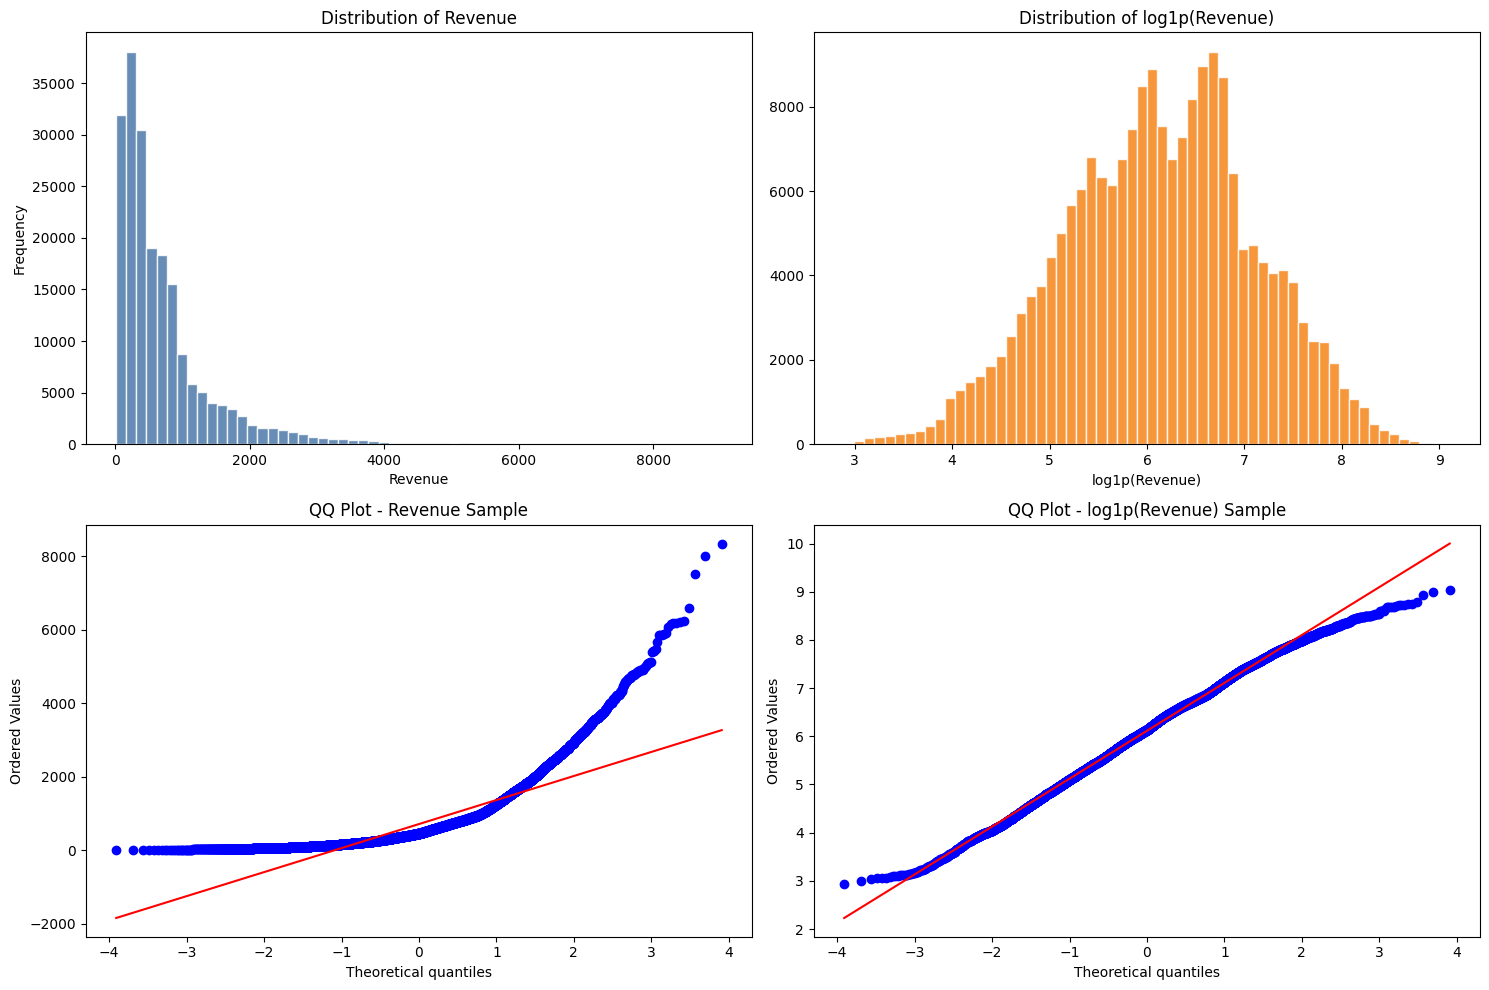

Revenue skewness: 2.5357
log1p(Revenue) skewness: -0.1462


In [11]:
from scipy import stats

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

axes[0, 0].hist(df[TARGET], bins=60, edgecolor="white", alpha=0.85, color="#4c78a8")
axes[0, 0].set_title("Distribution of Revenue")
axes[0, 0].set_xlabel("Revenue")
axes[0, 0].set_ylabel("Frequency")

axes[0, 1].hist(np.log1p(df[TARGET]), bins=60, edgecolor="white", alpha=0.85, color="#f58518")
axes[0, 1].set_title("Distribution of log1p(Revenue)")
axes[0, 1].set_xlabel("log1p(Revenue)")

stats.probplot(df[TARGET].sample(15000, random_state=RANDOM_STATE), dist="norm", plot=axes[1, 0])
axes[1, 0].set_title("QQ Plot - Revenue Sample")

stats.probplot(np.log1p(df[TARGET].sample(15000, random_state=RANDOM_STATE)), dist="norm", plot=axes[1, 1])
axes[1, 1].set_title("QQ Plot - log1p(Revenue) Sample")

plt.tight_layout()
plt.savefig(PLOT_DIR / "notebook_advanced_target_distribution.png", dpi=160)
plt.show()

print(f"Revenue skewness: {df[TARGET].skew():.4f}")
print(f"log1p(Revenue) skewness: {np.log1p(df[TARGET]).skew():.4f}")

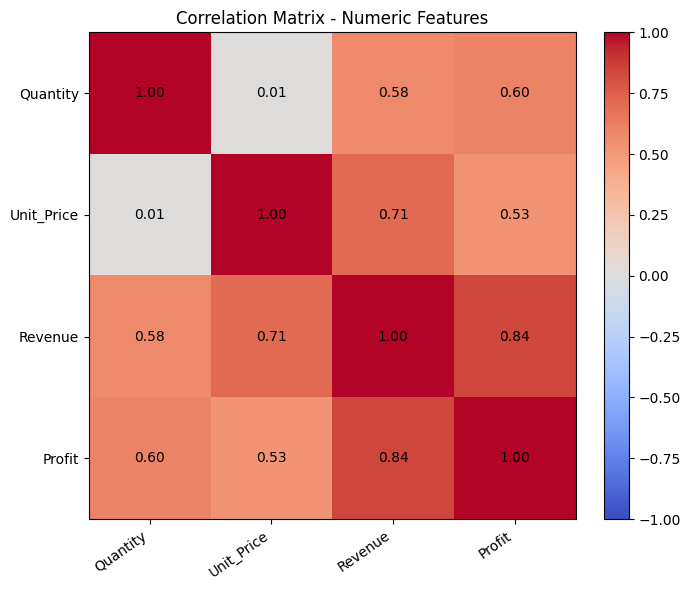

,Quantity,Unit_Price,Revenue,Profit
Quantity,1.0000,0.0073,0.5772,0.6025
Unit_Price,0.0073,1.0000,0.7062,0.5287
Revenue,0.5772,0.7062,1.0000,0.8413
Profit,0.6025,0.5287,0.8413,1.0000


In [12]:
numeric_cols = ["Quantity", "Unit_Price", "Revenue", "Profit"]
correlation_matrix = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(correlation_matrix, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(numeric_cols)))
ax.set_yticks(range(len(numeric_cols)))
ax.set_xticklabels(numeric_cols, rotation=35, ha="right")
ax.set_yticklabels(numeric_cols)
for i in range(len(numeric_cols)):
    for j in range(len(numeric_cols)):
        ax.text(j, i, f"{correlation_matrix.iloc[i, j]:.2f}", ha="center", va="center", color="black")
ax.set_title("Correlation Matrix - Numeric Features")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.savefig(PLOT_DIR / "notebook_numeric_correlation_heatmap.png", dpi=160)
plt.show()

correlation_matrix.round(4)

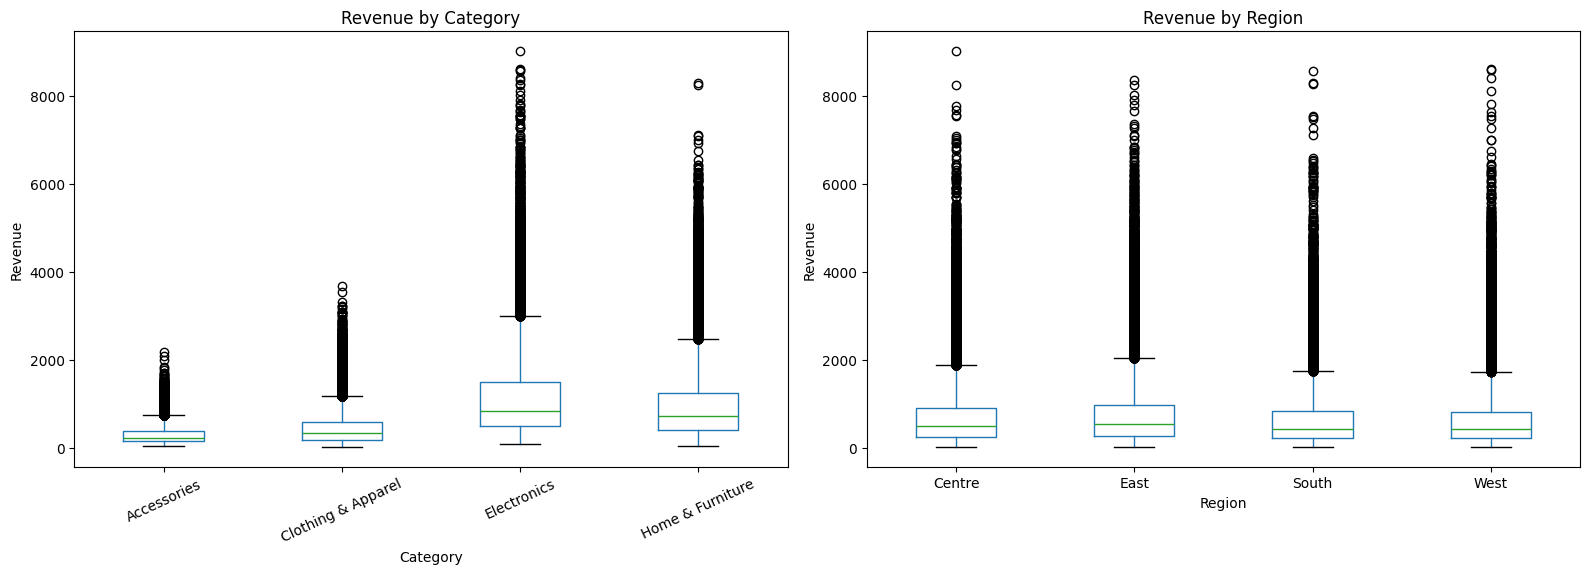

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

df.boxplot(column=TARGET, by="Category", ax=axes[0], grid=False)
axes[0].set_title("Revenue by Category")
axes[0].set_xlabel("Category")
axes[0].set_ylabel("Revenue")
axes[0].tick_params(axis="x", rotation=25)

df.boxplot(column=TARGET, by="Region", ax=axes[1], grid=False)
axes[1].set_title("Revenue by Region")
axes[1].set_xlabel("Region")
axes[1].set_ylabel("Revenue")

fig.suptitle("")
plt.tight_layout()
plt.savefig(PLOT_DIR / "notebook_revenue_boxplot_by_segments.png", dpi=160)
plt.show()

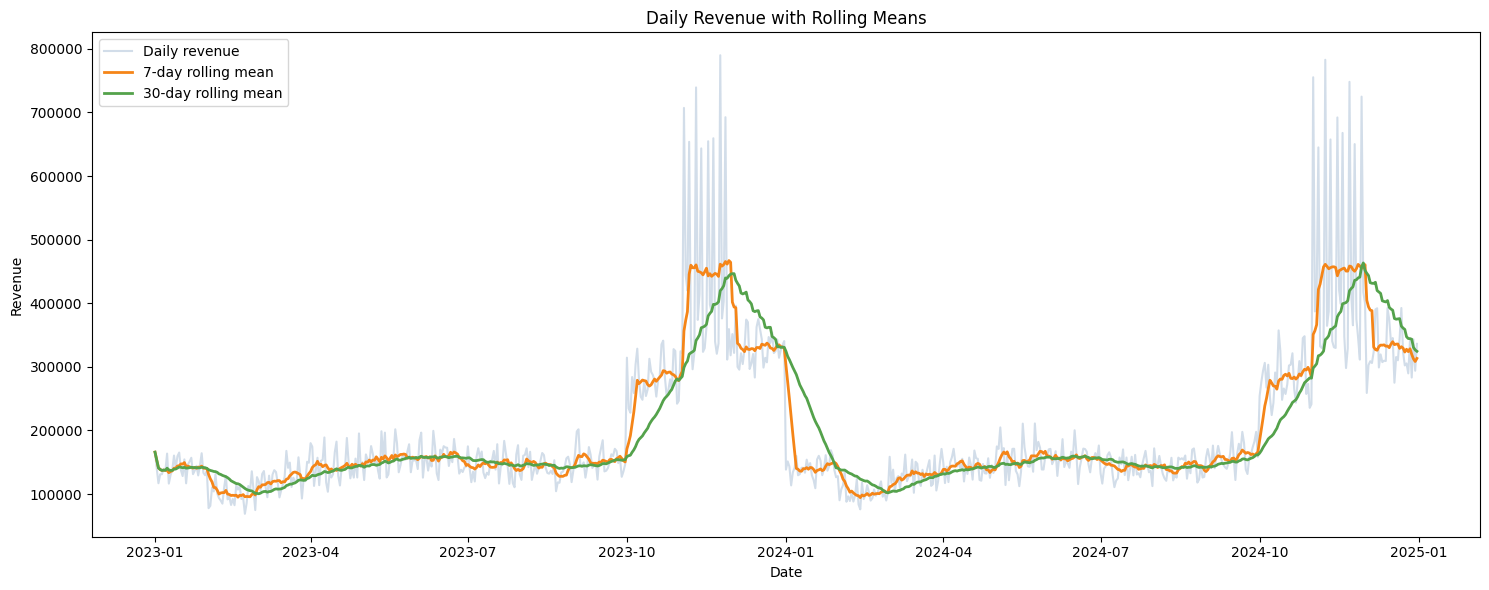

Insight:
- Rolling mean lam muot nhieu ngay doanh thu bien dong manh.
- Neu bai toan chuyen sang forecasting theo ngay/thang, cac lag va rolling features se rat huu ich.


In [14]:
daily_revenue = df.set_index(DATE_COLUMN).resample("D")[TARGET].sum()
daily_revenue_7d = daily_revenue.rolling(window=7, min_periods=1).mean()
daily_revenue_30d = daily_revenue.rolling(window=30, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(daily_revenue.index, daily_revenue.values, alpha=0.25, label="Daily revenue", color="#4c78a8")
ax.plot(daily_revenue_7d.index, daily_revenue_7d.values, label="7-day rolling mean", color="#f58518", linewidth=2)
ax.plot(daily_revenue_30d.index, daily_revenue_30d.values, label="30-day rolling mean", color="#54a24b", linewidth=2)
ax.set_title("Daily Revenue with Rolling Means")
ax.set_xlabel("Date")
ax.set_ylabel("Revenue")
ax.legend()
plt.tight_layout()
plt.savefig(PLOT_DIR / "notebook_daily_revenue_rolling_mean.png", dpi=160)
plt.show()

print("Insight:")
print("- Rolling mean lam muot nhieu ngay doanh thu bien dong manh.")
print("- Neu bai toan chuyen sang forecasting theo ngay/thang, cac lag va rolling features se rat huu ich.")

## 5.2. Bo Sung Day Du Cac Kieu Bieu Do Tu Notebook Mau

Phan nay bo sung day du hon cac dang visualization trong notebook tham khao, nhung dung dataset hien tai:

- Histogram + KDE-style density curve.
- Count plot dang bar chart.
- Bar chart tong doanh thu.
- Boxplot theo segment.
- Line chart theo thoi gian.
- Multi-panel EDA dashboard.
- Density comparison truoc/sau scaling.
- Scatter grid giua feature va target.

Cac bieu do nay giup EDA gan voi Data va business hon: san pham, gia, doanh thu, khu vuc va xu huong thoi gian.

In [ ]:
def plot_hist_with_kde(ax, values, bins, color, title, xlabel):
    values = pd.Series(values).dropna().astype(float)
    ax.hist(values, bins=bins, density=True, alpha=0.55, color=color, edgecolor="white")
    try:
        kde = stats.gaussian_kde(values.sample(min(len(values), 20000), random_state=RANDOM_STATE))
        x_grid = np.linspace(values.quantile(0.005), values.quantile(0.995), 300)
        ax.plot(x_grid, kde(x_grid), color="#222222", linewidth=2, label="KDE")
        ax.legend()
    except Exception as exc:
        print(f"KDE skipped for {title}: {exc}")
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Density")

category_counts = df["Category"].value_counts().sort_values(ascending=False)
category_revenue = df.groupby("Category")[TARGET].sum().sort_values(ascending=False)
monthly_sales_plot = df.set_index(DATE_COLUMN).resample("ME")[TARGET].sum()

fig = plt.figure(figsize=(20, 15))

ax1 = plt.subplot(2, 3, 1)
plot_hist_with_kde(ax1, df["Unit_Price"], 50, "skyblue", "Unit Price Distribution", "Unit_Price")

ax2 = plt.subplot(2, 3, 2)
plot_hist_with_kde(ax2, df[TARGET], 60, "salmon", "Revenue Distribution", "Revenue")

ax3 = plt.subplot(2, 3, 3)
ax3.bar(category_counts.index, category_counts.values, color=["#4c78a8", "#f58518", "#54a24b", "#b279a2"])
ax3.set_title("Order Count by Category")
ax3.set_xlabel("Category")
ax3.set_ylabel("Order Count")
ax3.tick_params(axis="x", rotation=25)

ax4 = plt.subplot(2, 3, 4)
ax4.bar(category_revenue.index, category_revenue.values, color=["#4c78a8", "#f58518", "#54a24b", "#b279a2"])
ax4.set_title("Total Revenue by Category")
ax4.set_xlabel("Category")
ax4.set_ylabel("Revenue")
ax4.tick_params(axis="x", rotation=25)

ax5 = plt.subplot(2, 3, 5)
box_data = [df.loc[df["Category"] == cat, TARGET] for cat in category_revenue.index]
ax5.boxplot(box_data, tick_labels=category_revenue.index, showfliers=False)
ax5.set_title("Revenue Boxplot by Category")
ax5.set_xlabel("Category")
ax5.set_ylabel("Revenue")
ax5.tick_params(axis="x", rotation=25)

ax6 = plt.subplot(2, 3, 6)
ax6.plot(monthly_sales_plot.index.astype(str), monthly_sales_plot.values, marker="o", color="purple", linewidth=2)
ax6.set_title("Monthly Revenue Trend")
ax6.set_xlabel("Month")
ax6.set_ylabel("Revenue")
ax6.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig(PLOT_DIR / "notebook_full_eda_dashboard_like_sample.png", dpi=160)
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler

scale_cols = ["Unit_Price", "Revenue"]
scaled_values = pd.DataFrame(
    StandardScaler().fit_transform(df[scale_cols]),
    columns=[f"{col}_scaled" for col in scale_cols]
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

plot_hist_with_kde(axes[0], df["Unit_Price"], 50, "#e45756", "Original Unit_Price Density", "Unit_Price")
plot_hist_with_kde(axes[1], scaled_values["Unit_Price_scaled"], 50, "#4c78a8", "Scaled Unit_Price Density", "Standardized Unit_Price")

plt.tight_layout()
plt.savefig(PLOT_DIR / "notebook_density_original_vs_scaled.png", dpi=160)
plt.show()

print("Scaling insight:")
print("- Linear models such as Ridge benefit from scaling numeric features.")
print("- Tree models are less sensitive to feature scale, but the shared preprocessing keeps the pipeline consistent.")

In [ ]:
scatter_features = ["Quantity", "Unit_Price", "Profit", "month", "day_of_week", "quarter"]
scatter_base = df.copy()
scatter_base["month"] = scatter_base[DATE_COLUMN].dt.month
scatter_base["day_of_week"] = scatter_base[DATE_COLUMN].dt.dayofweek
scatter_base["quarter"] = scatter_base[DATE_COLUMN].dt.quarter
scatter_df = scatter_base.sample(n=min(20000, len(scatter_base)), random_state=RANDOM_STATE)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for ax, col in zip(axes, scatter_features):
    ax.scatter(scatter_df[col], scatter_df[TARGET], alpha=0.22, s=9)
    ax.set_title(f"Revenue vs {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Revenue")
    ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.savefig(PLOT_DIR / "notebook_scatter_grid_features_vs_revenue.png", dpi=160)
plt.show()

print("Note:")
print("- Profit is shown only for EDA relationship analysis, not used as a modeling feature because it leaks post-sale information.")

## 6. Feature Engineering

Feature duoc tao theo requirements:
- Time features: `year`, `month`, `quarter`, `day_of_week`, `is_weekend`.
- Product popularity/history proxies: `product_order_count`, `product_avg_revenue`, `category_avg_revenue`.
- Geography history proxies: `state_avg_revenue`, `region_avg_revenue`.

Quan trong: aggregate features phai tinh tu train set, sau do map sang test set de giam time leakage.

In [15]:
def add_time_features(data: pd.DataFrame) -> pd.DataFrame:
    out = data.copy()
    out["year"] = out[DATE_COLUMN].dt.year
    out["month"] = out[DATE_COLUMN].dt.month
    out["quarter"] = out[DATE_COLUMN].dt.quarter
    out["day_of_week"] = out[DATE_COLUMN].dt.dayofweek
    out["is_weekend"] = out["day_of_week"].isin([5, 6]).astype(int)
    return out

def time_split(data: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    train = data[data[DATE_COLUMN] < TEST_START_DATE].copy()
    test = data[data[DATE_COLUMN] >= TEST_START_DATE].copy()
    assert train[DATE_COLUMN].max() < test[DATE_COLUMN].min()
    return train, test

def add_aggregate_features(train_data: pd.DataFrame, test_data: pd.DataFrame):
    train = train_data.copy()
    test = test_data.copy()
    global_mean = float(train[TARGET].mean())
    specs = {
        "product_order_count": ("Product_Name", train.groupby("Product_Name").size()),
        "product_avg_revenue": ("Product_Name", train.groupby("Product_Name")[TARGET].mean()),
        "category_avg_revenue": ("Category", train.groupby("Category")[TARGET].mean()),
        "state_avg_revenue": ("State", train.groupby("State")[TARGET].mean()),
        "region_avg_revenue": ("Region", train.groupby("Region")[TARGET].mean()),
    }
    mappings = {}
    defaults = {}
    for feature, (source_col, series) in specs.items():
        mapping = series.to_dict()
        mappings[feature] = mapping
        defaults[feature] = float(series.median() if feature.endswith("count") else global_mean)
        train[feature] = train[source_col].map(mapping).fillna(defaults[feature])
        test[feature] = test[source_col].map(mapping).fillna(defaults[feature])
    return train, test, mappings, defaults

df_features = add_time_features(df)
train_df, test_df = time_split(df_features)
train_df, test_df, aggregate_mappings, aggregate_defaults = add_aggregate_features(train_df, test_df)

print("Train rows:", len(train_df), train_df[DATE_COLUMN].min(), train_df[DATE_COLUMN].max())
print("Test rows:", len(test_df), test_df[DATE_COLUMN].min(), test_df[DATE_COLUMN].max())
display(train_df.head())

Train rows: 154048 2023-01-01 00:00:00 2024-09-30 00:00:00
Test rows: 45952 2024-10-01 00:00:00 2024-12-31 00:00:00


,Order_ID,Order_Date,Customer_Name,City,State,Region,Country,Category,Sub_Category,Product_Name,Quantity,Unit_Price,Revenue,Profit,year,month,quarter,day_of_week,is_weekend,product_order_count,product_avg_revenue,category_avg_revenue,state_avg_revenue,region_avg_revenue
0,1,2023-08-23,Bianca Brown,Jackson,Mississippi,South,United States,Accessories,Small Electronics,Phone Case,3,201.01,603.03,221.49,2023,8,3,2,0,3693,339.336198,282.361532,659.645464,659.073889
2,3,2024-01-29,Susan Valdez,Minneapolis,Minnesota,Centre,United States,Clothing & Apparel,Sportswear,Nike Air Force 1,1,68.19,68.19,25.47,2024,1,1,0,0,5470,484.755698,435.789813,735.254147,727.721272
4,5,2023-09-21,Catherine Gordon,Baltimore,Maryland,East,United States,Accessories,Bags,Backpack,1,216.63,216.63,42.46,2023,9,3,3,0,3803,288.971988,282.361532,779.262836,789.849534
7,8,2023-05-05,John Davis,Tulsa,Oklahoma,South,United States,Clothing & Apparel,Men's Wear,Levi's Jeans,1,329.29,329.29,65.91,2023,5,2,4,0,3706,460.984191,435.789813,682.651037,659.073889
8,9,2023-10-25,Edward Hicks,Salt Lake City,Utah,West,United States,Clothing & Apparel,Footwear,Timberland Boots,2,115.35,230.70,87.44,2023,10,4,2,0,2115,383.853083,435.789813,665.637206,653.219661


## 7. Feature Sets va Preprocessing

Cac cot bi loai khoi model chinh:
- `Order_ID`: chi la ID.
- `Customer_Name`: cardinality cao, co rui ro privacy/noise.
- `Country`: chi co 1 gia tri.
- `Profit`: post-sale outcome, leakage.
- `Revenue`: target.

In [16]:
DROP_FROM_FEATURES = ["Order_ID", "Customer_Name", "Country", "Profit", TARGET]
BASE_CATEGORICAL_FEATURES = ["City", "State", "Region", "Category", "Sub_Category", "Product_Name"]
TIME_FEATURES = ["year", "month", "quarter", "day_of_week", "is_weekend"]
AGG_FEATURES = ["product_order_count", "product_avg_revenue", "category_avg_revenue", "state_avg_revenue", "region_avg_revenue"]

def get_feature_sets(include_quantity: bool) -> tuple[list[str], list[str]]:
    numeric_features = ["Unit_Price"] + TIME_FEATURES + AGG_FEATURES
    if include_quantity:
        numeric_features = ["Quantity"] + numeric_features
    categorical_features = BASE_CATEGORICAL_FEATURES
    return numeric_features, categorical_features

def make_one_hot_preprocessor(numeric_features: list[str], categorical_features: list[str]) -> ColumnTransformer:
    numeric_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])
    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=True)),
    ])
    return ColumnTransformer([
        ("numeric", numeric_pipeline, numeric_features),
        ("categorical", categorical_pipeline, categorical_features),
    ], remainder="drop")

def make_ordinal_preprocessor(numeric_features: list[str], categorical_features: list[str]) -> ColumnTransformer:
    numeric_pipeline = Pipeline([("imputer", SimpleImputer(strategy="median"))])
    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("ordinal", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1, encoded_missing_value=-1)),
    ])
    return ColumnTransformer([
        ("numeric", numeric_pipeline, numeric_features),
        ("categorical", categorical_pipeline, categorical_features),
    ], remainder="drop")

def make_models(include_quantity: bool) -> dict[str, Pipeline]:
    numeric_features, categorical_features = get_feature_sets(include_quantity)
    one_hot = make_one_hot_preprocessor(numeric_features, categorical_features)
    ordinal = make_ordinal_preprocessor(numeric_features, categorical_features)
    return {
        "Baseline_Mean": Pipeline([("preprocess", one_hot), ("model", DummyRegressor(strategy="mean"))]),
        "Ridge": Pipeline([("preprocess", one_hot), ("model", Ridge(alpha=1.0))]),
        "DecisionTree": Pipeline([("preprocess", one_hot), ("model", DecisionTreeRegressor(max_depth=16, min_samples_leaf=40, random_state=RANDOM_STATE))]),
        "RandomForest": Pipeline([("preprocess", one_hot), ("model", RandomForestRegressor(n_estimators=20, max_depth=12, min_samples_leaf=80, random_state=RANDOM_STATE, n_jobs=1))]),
        "HistGradientBoosting": Pipeline([("preprocess", ordinal), ("model", HistGradientBoostingRegressor(max_iter=100, learning_rate=0.08, l2_regularization=0.05, random_state=RANDOM_STATE))]),
    }

## 7.1. Giai Thich Thuat Toan: Linear Regression va SVR

Phan nay bo sung ly thuyet tu notebook tham khao, nhung giu trong notebook chinh de phuc vu bao cao.

### Linear Regression

Linear Regression gia dinh target co quan he tuyen tinh voi cac feature:

$$
\hat{y} = w_0 + w_1x_1 + w_2x_2 + ... + w_px_p
$$

Voi bai nay:

- $y$ la `Revenue`.
- $x$ co the la `Unit_Price`, time features, product/category/geography features sau encoding.
- Model hoc cac trong so $w$ sao cho sai so du doan nho nhat.

Ham mat mat pho bien la Mean Squared Error:

$$
MSE = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2
$$

Ridge Regression la bien the cua Linear Regression co them regularization:

$$
Loss = MSE + \alpha\sum_{j=1}^{p}w_j^2
$$

Regularization giup giam overfitting khi co nhieu feature sau one-hot encoding.

### SVR - Support Vector Regression

SVR la phien ban regression cua Support Vector Machine. Thay vi chi toi uu sai so trung binh, SVR tao mot vung dung sai epsilon quanh duong du doan:

$$
|y_i - \hat{y}_i| \leq \epsilon
$$

Neu diem nam trong vung epsilon, model xem sai so la chap nhan duoc. Neu nam ngoai vung epsilon, diem do moi bi phat.

Epsilon-insensitive loss:

$$
L_\epsilon(y, \hat{y}) = \max(0, |y - \hat{y}| - \epsilon)
$$

SVR phu hop de giai thich hoc thuat va xu ly mot so bai regression co bien khong qua lon. Tuy nhien voi dataset 200,000 dong va nhieu categorical features, SVR thuong cham hon tree boosting/linear model pipeline. Vi vay notebook chinh khong train SVR tren full data, nhung van giai thich thuat toan trong phan ly thuyet.

## 8. Model Training va Evaluation

## 8.1. Cong Thuc Evaluation Metrics

Cac metric dung de danh gia model regression:

### MAE - Mean Absolute Error

$$
MAE = \frac{1}{n}\sum_{i=1}^{n}|y_i - \hat{y}_i|
$$

MAE cho biet trung binh model du doan lech bao nhieu don vi doanh thu. De giai thich voi business.

### MSE - Mean Squared Error

$$
MSE = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2
$$

MSE phat nang cac loi lon, nhung don vi la binh phuong doanh thu nen kho dien giai truc tiep.

### RMSE - Root Mean Squared Error

$$
RMSE = \sqrt{MSE}
$$

RMSE quay ve cung don vi voi target va phat nang cac loi lon. Phu hop vi `Revenue` co outlier va skew.

### R2 - Coefficient of Determination

$$
R^2 = 1 - \frac{\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}{\sum_{i=1}^{n}(y_i - \bar{y})^2}
$$

R2 cho biet model giai thich duoc bao nhieu phan tram bien dong cua target. R2 gan 1 la tot, gan 0 la chi ngang baseline mean, am la te hon baseline.

In [17]:
def regression_metrics(y_true, y_pred) -> dict[str, float]:
    mse = mean_squared_error(y_true, y_pred)
    return {
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "MSE": float(mse),
        "RMSE": float(np.sqrt(mse)),
        "R2": float(r2_score(y_true, y_pred)),
    }

def train_variant(train_data: pd.DataFrame, test_data: pd.DataFrame, variant: str, include_quantity: bool):
    numeric_features, categorical_features = get_feature_sets(include_quantity)
    feature_columns = numeric_features + categorical_features
    forbidden = {TARGET, "Profit", "Order_ID", "Customer_Name", "Country"}
    assert TARGET not in feature_columns
    assert forbidden.isdisjoint(feature_columns)
    if not include_quantity:
        assert "Quantity" not in feature_columns

    x_train = train_data[feature_columns]
    y_train = train_data[TARGET]
    x_test = test_data[feature_columns]
    y_test = test_data[TARGET]

    rows = []
    fitted = {}
    preds = {}
    for model_name, model in make_models(include_quantity).items():
        print(f"Training {variant} / {model_name}...")
        model.fit(x_train, y_train)
        y_pred = model.predict(x_test)
        rows.append({
            "variant": variant,
            "model": model_name,
            "include_quantity": include_quantity,
            "feature_count": len(feature_columns),
            **regression_metrics(y_test, y_pred),
        })
        fitted[model_name] = model
        preds[model_name] = y_pred
    best_row = min(rows, key=lambda x: x["RMSE"])
    return rows, fitted[best_row["model"]], preds[best_row["model"]], feature_columns

model_a_rows, model_a_best, model_a_pred, model_a_features = train_variant(train_df, test_df, "Model_A_With_Quantity", True)
model_b_rows, model_b_best, model_b_pred, model_b_features = train_variant(train_df, test_df, "Model_B_No_Quantity", False)

metrics_df = pd.DataFrame(model_a_rows + model_b_rows).sort_values(["variant", "RMSE"])
display(metrics_df[["variant", "model", "MAE", "MSE", "RMSE", "R2", "feature_count"]].round(4))

Training Model_A_With_Quantity / Baseline_Mean...
Training Model_A_With_Quantity / Ridge...
Training Model_A_With_Quantity / DecisionTree...
Training Model_A_With_Quantity / RandomForest...
Training Model_A_With_Quantity / HistGradientBoosting...
Training Model_B_No_Quantity / Baseline_Mean...
Training Model_B_No_Quantity / Ridge...
Training Model_B_No_Quantity / DecisionTree...
Training Model_B_No_Quantity / RandomForest...
Training Model_B_No_Quantity / HistGradientBoosting...


,variant,model,MAE,MSE,RMSE,R2,feature_count
4,Model_A_With_Quantity,HistGradientBoosting,5.1224,190.1856,13.7908,0.9997,18
2,Model_A_With_Quantity,DecisionTree,3.3736,985.2579,31.3888,0.9982,18
3,Model_A_With_Quantity,RandomForest,5.0155,1996.1189,44.6779,0.9964,18
1,Model_A_With_Quantity,Ridge,199.3828,95778.0390,309.4803,0.8267,18
0,Model_A_With_Quantity,Baseline_Mean,509.8041,552643.4202,743.3999,-0.0000,18
6,Model_B_No_Quantity,Ridge,331.2022,272432.2811,521.9505,0.5070,17
9,Model_B_No_Quantity,HistGradientBoosting,330.4474,272520.5316,522.0350,0.5069,17
8,Model_B_No_Quantity,RandomForest,331.0552,272940.5794,522.4372,0.5061,17
7,Model_B_No_Quantity,DecisionTree,340.2276,287986.6855,536.6439,0.4789,17
5,Model_B_No_Quantity,Baseline_Mean,509.8041,552643.4202,743.3999,-0.0000,17


## 9. Model Interpretation va Selection

Model A co metric rat cao vi dung `Quantity`, trong khi `Revenue = Quantity * Unit_Price`. Do do Model A duoc xem la leakage demo.

Model B khong dung `Quantity`, nen phu hop hon neu cong ty muon du doan doanh thu truoc khi biet so luong ban.

In [18]:
best_business_row = metrics_df[metrics_df["variant"] == "Model_B_No_Quantity"].sort_values("RMSE").iloc[0].to_dict()
print("Selected final model:")
print(best_business_row)

print("\nModel A best, for leakage comparison only:")
display(metrics_df[metrics_df["variant"] == "Model_A_With_Quantity"].head(1).round(4))

print("\nModel B best, selected for deployment:")
display(metrics_df[metrics_df["variant"] == "Model_B_No_Quantity"].head(1).round(4))

Selected final model:
{'variant': 'Model_B_No_Quantity', 'model': 'Ridge', 'include_quantity': False, 'feature_count': 17, 'MAE': 331.20224255191886, 'MSE': 272432.281134545, 'RMSE': 521.9504585059246, 'R2': 0.5070370412224015}

Model A best, for leakage comparison only:


,variant,model,include_quantity,feature_count,MAE,MSE,RMSE,R2
4,Model_A_With_Quantity,HistGradientBoosting,True,18,5.1224,190.1856,13.7908,0.9997



Model B best, selected for deployment:


,variant,model,include_quantity,feature_count,MAE,MSE,RMSE,R2
6,Model_B_No_Quantity,Ridge,False,17,331.2022,272432.2811,521.9505,0.507


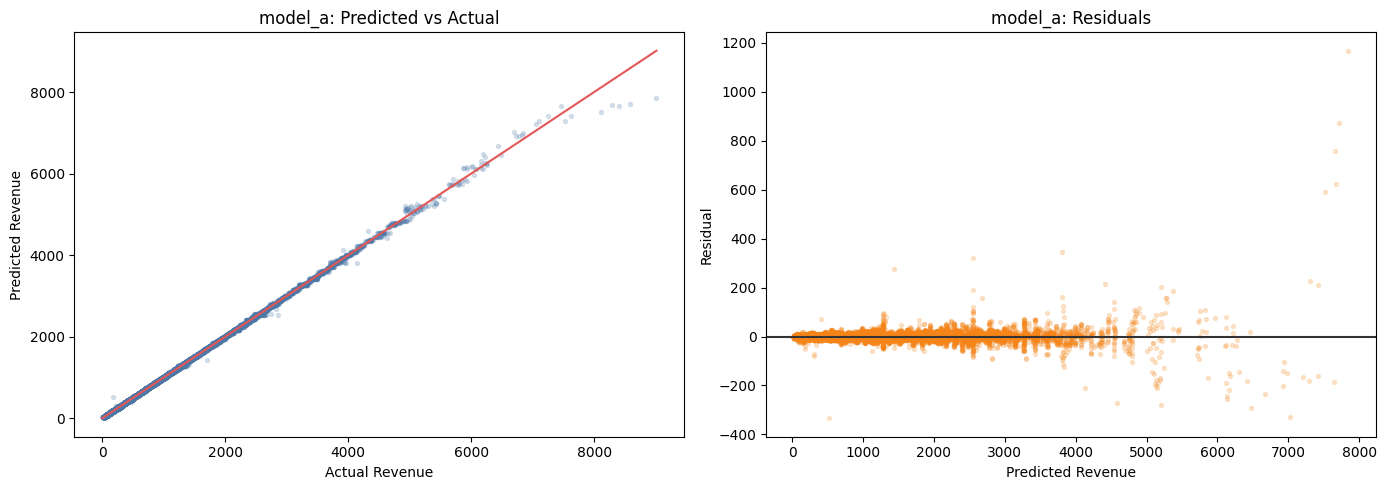

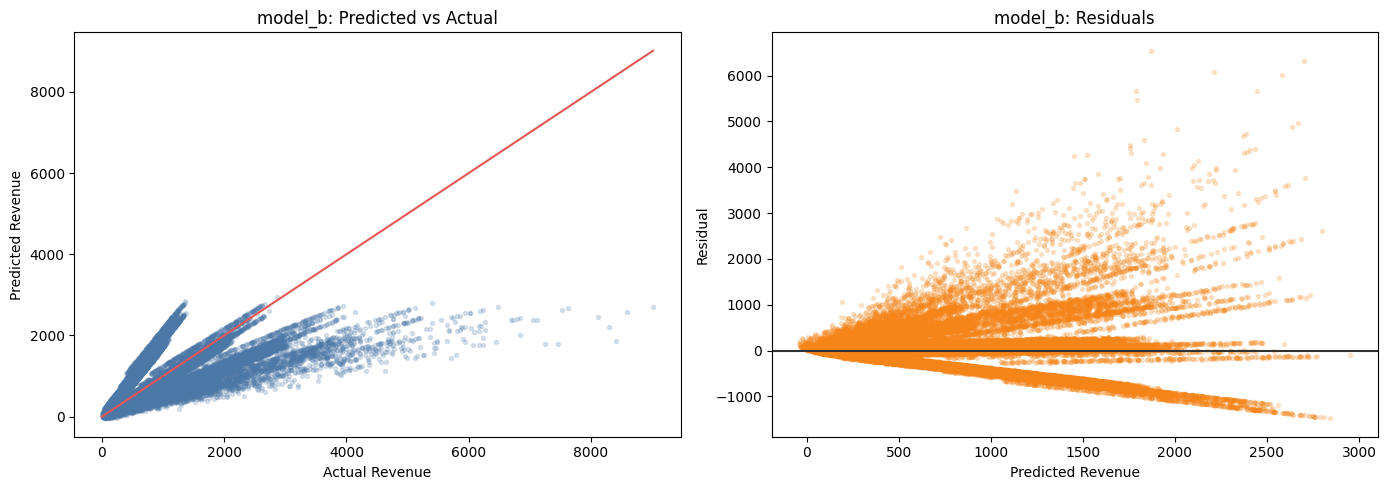

In [19]:
def plot_predictions(y_true, y_pred, title_prefix: str):
    residuals = y_true - y_pred
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].scatter(y_true, y_pred, alpha=0.2, s=8, color="#4c78a8")
    max_value = max(float(y_true.max()), float(np.max(y_pred)))
    axes[0].plot([0, max_value], [0, max_value], color="#e45756")
    axes[0].set_title(f"{title_prefix}: Predicted vs Actual")
    axes[0].set_xlabel("Actual Revenue")
    axes[0].set_ylabel("Predicted Revenue")

    axes[1].scatter(y_pred, residuals, alpha=0.2, s=8, color="#f58518")
    axes[1].axhline(0, color="#333333")
    axes[1].set_title(f"{title_prefix}: Residuals")
    axes[1].set_xlabel("Predicted Revenue")
    axes[1].set_ylabel("Residual")
    plt.tight_layout()
    plt.savefig(PLOT_DIR / f"notebook_{title_prefix.lower()}_prediction_plots.png", dpi=160)
    plt.show()

plot_predictions(test_df[TARGET], model_a_pred, "model_a")
plot_predictions(test_df[TARGET], model_b_pred, "model_b")

In [20]:
residual_analysis = test_df[[DATE_COLUMN, "Category"]].copy()
residual_analysis["actual"] = test_df[TARGET].to_numpy()
residual_analysis["predicted"] = model_b_pred
residual_analysis["residual"] = residual_analysis["actual"] - residual_analysis["predicted"]

print("Mean residual by category:")
display(residual_analysis.groupby("Category")["residual"].agg(["mean", "median", "std", "count"]).round(2))

print("Mean residual by month:")
display(residual_analysis.groupby(residual_analysis[DATE_COLUMN].dt.to_period("M"))["residual"].agg(["mean", "median", "std", "count"]).round(2))

Mean residual by category:


,mean,median,std,count
Category,,,,
Accessories,-0.70,-33.14,174.01,7984
Clothing & Apparel,1.19,-22.53,294.51,14561
Electronics,8.02,-84.85,750.24,11697
Home & Furniture,-3.05,-58.45,615.10,11710


Mean residual by month:


,mean,median,std,count
Order_Date,,,,
2024-10,4.43,-39.37,518.84,12222
2024-11,-1.95,-45.57,527.80,19469
2024-12,3.76,-40.44,516.57,14261


## 9.1. Bieu Do Chan Doan Model Bo Sung Theo Notebook Mau

Phan nay bo sung cac dang bieu do trong notebook tham khao sau khi da train model:

- Actual vs Predicted theo thu tu thoi gian cua test set.
- Epsilon-tube style diagnostic: minh hoa vung sai so chap nhan duoc quanh duong y=x.
- Feature weight chart cho final Ridge model.

Luu y: notebook nay khong train SVR tren full dataset; epsilon tube o day la diagnostic visualization lay cam hung tu SVR, dung nguong epsilon bang MAE cua final model.

In [ ]:
ordered_test = test_df.copy()
ordered_test["prediction"] = model_b_pred
ordered_test = ordered_test.sort_values(DATE_COLUMN).reset_index(drop=True)
plot_n = min(500, len(ordered_test))

plt.figure(figsize=(15, 6))
plt.plot(ordered_test.loc[:plot_n - 1, TARGET].to_numpy(), label="Actual", linewidth=2)
plt.plot(ordered_test.loc[:plot_n - 1, "prediction"].to_numpy(), label="Predicted", linewidth=2)
plt.title("Model B - Actual vs Predicted Revenue Over Test Order")
plt.xlabel("Test sample index sorted by date")
plt.ylabel("Revenue")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(PLOT_DIR / "notebook_model_b_actual_vs_predicted_line.png", dpi=160)
plt.show()

In [ ]:
y_true_model_b = test_df[TARGET].to_numpy()
y_pred_model_b = np.asarray(model_b_pred)
epsilon_display = mean_absolute_error(y_true_model_b, y_pred_model_b)

plt.figure(figsize=(10, 8))
min_val = min(y_true_model_b.min(), y_pred_model_b.min())
max_val = max(y_true_model_b.max(), y_pred_model_b.max())
padding = (max_val - min_val) * 0.05
ideal_line = np.linspace(min_val - padding, max_val + padding, 200)

plt.fill_between(
    ideal_line,
    ideal_line - epsilon_display,
    ideal_line + epsilon_display,
    color="#87CEEB",
    alpha=0.35,
    label=f"Epsilon-style tube (+/- MAE = {epsilon_display:.2f})",
)
plt.plot(ideal_line, ideal_line + epsilon_display, linestyle="--", color="#104E8B", linewidth=2)
plt.plot(ideal_line, ideal_line - epsilon_display, linestyle="--", color="#104E8B", linewidth=2)
plt.plot(ideal_line, ideal_line, label="Ideal line (y = x)", linewidth=2.5, color="#1f77b4")

sample_idx = np.random.default_rng(RANDOM_STATE).choice(len(y_true_model_b), size=min(5000, len(y_true_model_b)), replace=False)
plt.scatter(y_true_model_b[sample_idx], y_pred_model_b[sample_idx], color="#ff7f0e", edgecolors="white", linewidth=0.3, alpha=0.55, s=25, label="Test predictions")
plt.title("Model B - Epsilon-Tube Style Prediction Diagnostic")
plt.xlabel("Actual Revenue")
plt.ylabel("Predicted Revenue")
plt.legend(loc="upper left")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(PLOT_DIR / "notebook_model_b_epsilon_tube_style.png", dpi=160)
plt.show()

In [ ]:
final_estimator = model_b_best.named_steps["model"]
preprocessor = model_b_best.named_steps["preprocess"]

if hasattr(final_estimator, "coef_") and hasattr(preprocessor, "get_feature_names_out"):
    feature_names = preprocessor.get_feature_names_out()
    coef = final_estimator.coef_
    coef_df = pd.DataFrame({"feature": feature_names, "weight": coef})
    coef_df["abs_weight"] = coef_df["weight"].abs()
    top_coef = coef_df.sort_values("abs_weight", ascending=False).head(15).sort_values("abs_weight")

    plt.figure(figsize=(11, 7))
    colors = np.where(top_coef["weight"] >= 0, "#54a24b", "#e45756")
    plt.barh(top_coef["feature"], top_coef["abs_weight"], color=colors)
    plt.title("Top 15 Absolute Feature Weights - Final Ridge Model")
    plt.xlabel("Absolute Weight")
    plt.ylabel("Feature")
    plt.grid(True, axis="x", alpha=0.3)
    plt.tight_layout()
    plt.savefig(PLOT_DIR / "notebook_final_ridge_feature_weights.png", dpi=160)
    plt.show()

    display(coef_df.sort_values("abs_weight", ascending=False).head(15).round(4))
else:
    print("Final model does not expose linear coefficients; skipping feature-weight plot.")

## 10. Save Reports va Artifacts

In [21]:
eda_summary = {
    "data_checks": data_checks,
    "target_summary": {k: float(v) for k, v in target_summary.items()},
    "top_category_revenue": top_category.reset_index().to_dict("records"),
    "top_sub_category_revenue": top_sub_category.reset_index().to_dict("records"),
    "top_product_revenue": top_product.reset_index().to_dict("records"),
    "top_region_revenue": top_region.reset_index().to_dict("records"),
    "top_state_revenue": top_state.reset_index().to_dict("records"),
    "top_city_revenue": top_city.reset_index().to_dict("records"),
}

metrics_payload = {
    "selected_model": best_business_row,
    "metrics": metrics_df.to_dict("records"),
    "feature_columns": model_b_features,
    "test_start_date": str(TEST_START_DATE.date()),
    "excluded_columns": DROP_FROM_FEATURES,
    "note": "Final model excludes Quantity to avoid leakage. Model A is included only for comparison.",
}

(REPORT_DIR / "notebook_eda_summary.json").write_text(json.dumps(eda_summary, indent=2, default=str), encoding="utf-8")
(ARTIFACT_DIR / "notebook_metrics.json").write_text(json.dumps(metrics_payload, indent=2, default=str), encoding="utf-8")
(ARTIFACT_DIR / "notebook_feature_columns.json").write_text(json.dumps(model_b_features, indent=2), encoding="utf-8")

joblib.dump(model_b_best, ARTIFACT_DIR / "notebook_best_model.joblib")
joblib.dump(
    {
        "model": model_b_best,
        "selected_model": best_business_row,
        "feature_columns": model_b_features,
        "aggregate_mappings": aggregate_mappings,
        "aggregate_defaults": aggregate_defaults,
        "date_column": DATE_COLUMN,
        "date_format": DATE_FORMAT,
        "target": TARGET,
    },
    ARTIFACT_DIR / "notebook_model_bundle.joblib",
)

print("Saved notebook artifacts to:", ARTIFACT_DIR)
print("Saved notebook reports to:", REPORT_DIR)

Saved notebook artifacts to: /Users/quangmanh/Project/lab02/artifacts
Saved notebook reports to: /Users/quangmanh/Project/lab02/reports


## 11. Demo Prediction

Demo nay tao mot input moi, sinh cac engineered features, sau do predict `Revenue` bang final Model B.

In [22]:
def prepare_single_input(raw: dict[str, Any]) -> pd.DataFrame:
    row = pd.DataFrame([raw])
    row[DATE_COLUMN] = pd.to_datetime(row[DATE_COLUMN], format=DATE_FORMAT, errors="coerce")
    if row[DATE_COLUMN].isna().any():
        raise ValueError(f"{DATE_COLUMN} must match format {DATE_FORMAT}, e.g. 12-15-24")
    row = add_time_features(row)
    source_by_aggregate = {
        "product_order_count": "Product_Name",
        "product_avg_revenue": "Product_Name",
        "category_avg_revenue": "Category",
        "state_avg_revenue": "State",
        "region_avg_revenue": "Region",
    }
    for feature_name, source_col in source_by_aggregate.items():
        row[feature_name] = row[source_col].map(aggregate_mappings[feature_name]).fillna(aggregate_defaults[feature_name])
    return row[model_b_features]

sample_order = {
    "Order_Date": "12-15-24",
    "City": "Boston",
    "State": "Massachusetts",
    "Region": "East",
    "Category": "Electronics",
    "Sub_Category": "Laptops",
    "Product_Name": "MacBook Air",
    "Unit_Price": 999.99,
}

sample_features = prepare_single_input(sample_order)
sample_prediction = float(model_b_best.predict(sample_features)[0])
print("Predicted revenue:", round(sample_prediction, 2))
display(sample_features)

Predicted revenue: 2175.44


,Unit_Price,year,month,quarter,day_of_week,is_weekend,product_order_count,product_avg_revenue,category_avg_revenue,state_avg_revenue,region_avg_revenue,City,State,Region,Category,Sub_Category,Product_Name
0,999.99,2024,12,4,6,1,3035,1868.759858,1118.48317,792.325884,789.849534,Boston,Massachusetts,East,Electronics,Laptops,MacBook Air


## 12. Final Conclusion

- Dataset phu hop voi bai sales prediction: co product, price, quantity, geography, revenue, profit va date.
- Data sach: khong missing, khong duplicate, date parse duoc 100%.
- `Revenue` la target hop ly nhat.
- `Profit` bi loai vi la bien hau nghiem.
- `Country` bi loai vi chi co 1 gia tri.
- `Customer_Name` bi loai khoi model chinh vi cardinality cao va khong phu hop lam demographic feature.
- Model A co metric rat cao nhung co leakage vi dung `Quantity`.
- Model B khong dung `Quantity`, nen thuc te hon va duoc chon lam final model.
- De cai thien trong tuong lai, nen bo sung campaign, discount, ad spend, rating, review, inventory va customer history that.